# Modelo CatBoost - Predicción de demanda mensual

Este notebook entrena un modelo CatBoost para predecir la cantidad mensual de cada combinación Categoría+Producto+Presentación. El dataset de entrada es el generado por `02_feature_engineering.ipynb`.

> ⚠️ Con solo 9 meses de datos por serie tras aplicar los lags, los resultados deben interpretarse con cautela. Este ejercicio tiene fines de aprendizaje.

### 1. Importación de bibliotecas y carga de datos

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
BASE_DIR = os.path.dirname(os.getcwd())
INPUT_PATH = os.path.join(BASE_DIR, 'data', 'processed', 'datos_features.csv')
OUTPUT_PATH = os.path.join(BASE_DIR, 'results', 'predicciones', 'predicciones.csv')

df = pd.read_csv(INPUT_PATH)
df['Fecha_mes'] = pd.to_datetime(df['Fecha_mes'])

print('Shape:', df.shape)
display(df.head())

Shape: (441, 15)


,Categoría,Producto,Presentación,anio,mes,Fecha_mes,cantidad_total_mes,num_pedidos,num_clientes,lag_1,lag_2,lag_3,media_movil_3,mes_seno,mes_coseno
0,Cremas,Crema agria,Tarrina 200g,2024,4,2024-04-01,16396,34,18,21640.0,13353.0,12876.0,15956.333333,8.660254e-01,-0.500000
1,Cremas,Crema agria,Tarrina 200g,2024,5,2024-05-01,18317,36,16,16396.0,21640.0,13353.0,17129.666667,5.000000e-01,-0.866025
2,Cremas,Crema agria,Tarrina 200g,2024,6,2024-06-01,12906,28,16,18317.0,16396.0,21640.0,18784.333333,1.224647e-16,-1.000000
3,Cremas,Crema agria,Tarrina 200g,2024,7,2024-07-01,20483,36,18,12906.0,18317.0,16396.0,15873.000000,-5.000000e-01,-0.866025
4,Cremas,Crema agria,Tarrina 200g,2024,8,2024-08-01,18346,36,16,20483.0,12906.0,18317.0,17235.333333,-8.660254e-01,-0.500000


### 2. Train/test split

Se respeta el orden temporal: se entrena con los primeros 8 meses disponibles y se valida con el último mes. Esto simula el escenario real en el que el modelo predice el mes siguiente a partir del histórico conocido.

In [5]:
meses_ordenados = sorted(df['Fecha_mes'].unique())

mes_test       = meses_ordenados[-1]
mes_validation = meses_ordenados[-2]

train = df[df['Fecha_mes'] < mes_validation].copy()
val   = df[df['Fecha_mes'] == mes_validation].copy()
test  = df[df['Fecha_mes'] == mes_test].copy()

print(f'Train:      hasta {meses_ordenados[-3].strftime("%Y-%m")} — {len(train)} filas')
print(f'Validation: {mes_validation.strftime("%Y-%m")} — {len(val)} filas')
print(f'Test:       {mes_test.strftime("%Y-%m")} — {len(test)} filas')

Train:      hasta 2024-10 — 343 filas
Validation: 2024-11 — 49 filas
Test:       2024-12 — 49 filas


### 3. Definición de features y variable objetivo

In [6]:
FEATURES = [
    'Categoría', 'Producto', 'Presentación',
    'lag_1', 'lag_2', 'lag_3',
    'media_movil_3',
    'mes', 'mes_seno', 'mes_coseno'
]
TARGET = 'cantidad_total_mes'
CAT_FEATURES = ['Categoría', 'Producto', 'Presentación']

X_train = train[FEATURES]
y_train = train[TARGET]

X_val = val[FEATURES]
y_val = val[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

### 4. Entrenamiento CatBoost

CatBoost maneja las variables categóricas de forma nativa, sin necesidad de encoding previo. Se indica explícitamente qué columnas son categóricas mediante `cat_features`.

In [7]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=4,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train, y_train,
    cat_features=CAT_FEATURES,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

0:	learn: 6632.2702911	test: 6359.1939860	best: 6359.1939860 (0)	total: 164ms	remaining: 1m 21s
100:	learn: 2179.0976596	test: 2024.7835732	best: 1926.1535840 (66)	total: 2.77s	remaining: 11s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1926.153584
bestIteration = 66

Shrink model to first 67 iterations.


### 5. Evaluación

Se evalúa el modelo sobre el mes de validación con tres métricas:

- **MAE** — error absoluto medio en unidades
- **RMSE** — penaliza más los errores grandes
- **R²** — proporción de varianza explicada por el modelo (1.0 sería perfecto, 0.0 equivale a predecir siempre la media)

In [8]:
y_pred_val = model.predict(X_val)

print("--- Validación ---")
print(f'MAE:  {mean_absolute_error(y_val, y_pred_val):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_val)):.2f}')
print(f'R²:   {r2_score(y_val, y_pred_val):.4f}')

--- Validación ---
MAE:  1550.80
RMSE: 1926.15
R²:   0.9144


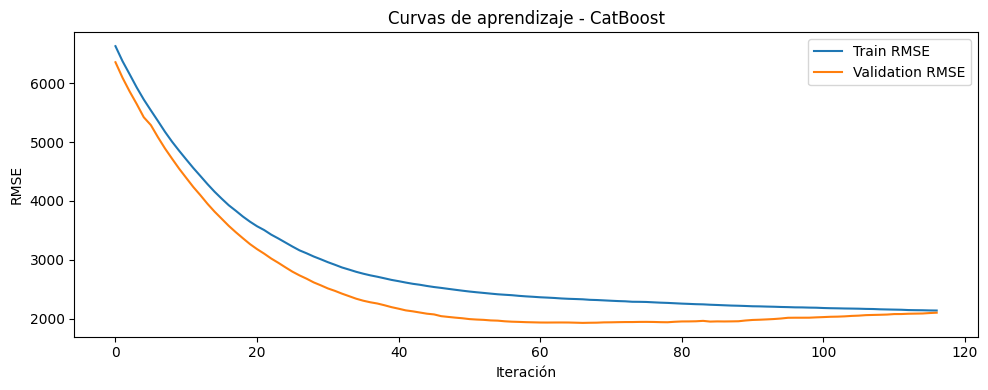

In [11]:
# Curvas de aprendizaje
evals = model.get_evals_result()

train_rmse = evals['learn']['RMSE']
val_rmse   = evals['validation']['RMSE']

plt.figure(figsize=(10, 4))
plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse, label='Validation RMSE')
plt.xlabel('Iteración')
plt.ylabel('RMSE')
plt.title('Curvas de aprendizaje - CatBoost')
plt.legend()
plt.tight_layout()

ruta_train = os.path.join(BASE_DIR, 'results', 'figures', 'train')
os.makedirs(ruta_train, exist_ok=True)
plt.savefig(os.path.join(ruta_train, 'curvas_aprendizaje.png'), dpi=150, bbox_inches='tight')

plt.show()

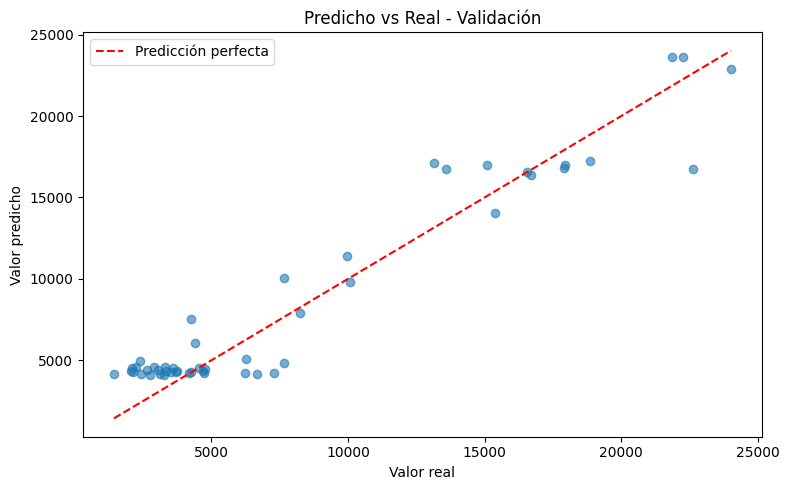

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(y_val, y_pred_val, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', label='Predicción perfecta')
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Predicho vs Real - Validación')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(ruta_train, 'predicho_vs_real.png'), dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Guardar
ruta_modelo = os.path.join(BASE_DIR, 'results', 'modelo', 'catboost_model.cbm')
os.makedirs(os.path.dirname(ruta_modelo), exist_ok=True)
model.save_model(ruta_modelo)
print(f' Modelo guardado en: {ruta_modelo}')

 Modelo guardado en: c:\Users\esthe\OneDrive\Escritorio\PROJECTS\dairy-demand-forecasting\results\modelo\catboost_model.cbm


- R² de 0.91 indica que el modelo explica el 91% de la varianza de la demanda, lo cual es un valor alto.
- MAE de 1550 unidades es un error absoluto muy elevado. Significa que de media el modelo se equivoca en 1550 unidades por combinación Producto+Presentación al mes. Dependiendo del volumen de ventas habitual esto puede ser crítico para la gestión de stock.
- RMSE mayor que MAE (1926 vs 1550) indica que hay algunas predicciones con errores especialmente grandes que están penalizando el resultado.


> ⚠️ Estos resultados están calculados sobre un único mes de validación con 49 combinaciones Producto+Presentación. Eso es estadísticamente muy poco — el R² de 0.91 puede ser fruto de que ese mes concreto era "fácil" de predecir, no de que el modelo generalice bien.

### 6. Test

In [14]:
model = CatBoostRegressor()
model.load_model(ruta_modelo)
print(f'Modelo cargado desde: {ruta_modelo}')

Modelo cargado desde: c:\Users\esthe\OneDrive\Escritorio\PROJECTS\dairy-demand-forecasting\results\modelo\catboost_model.cbm


In [15]:
print("--- Test ---")
y_pred_test = model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2   = r2_score(y_test, y_pred_test)
print(f'MAE:  {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²:   {r2:.4f}')

--- Test ---
MAE:  1984.32
RMSE: 2610.50
R²:   0.8540


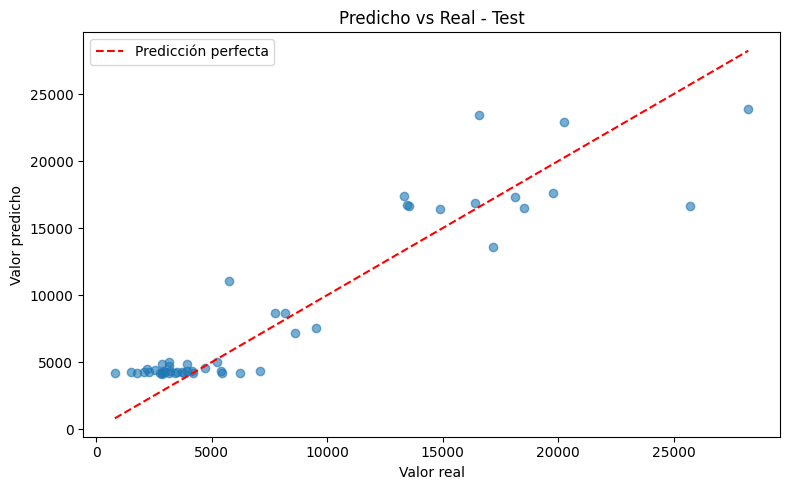

In [ ]:
ruta_test = os.path.join(BASE_DIR, 'results', 'figures', 'test')
os.makedirs(ruta_test, exist_ok=True)


# Predicho vs Real
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Predicción perfecta')
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Predicho vs Real - Test')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(ruta_test, 'predicho_vs_real.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7. Predicción del mes siguiente

Para predecir el mes t+1 se construye una nueva fila por cada combinación Producto+Presentación usando el último mes disponible como base para los lags.

In [18]:
# Último mes real disponible en todo el dataset
ultimo_mes_real = df['Fecha_mes'].max()
siguiente_mes = ultimo_mes_real + pd.DateOffset(months=1)

# Para cada combinación, cogemos los últimos 3 meses ordenados
grupo = ['Categoría', 'Producto', 'Presentación']

ultimos = (
    df.sort_values(grupo + ['Fecha_mes'])
    .groupby(grupo)
    .tail(3)
)

# Lag 1 = último mes, lag 2 = penúltimo, lag 3 = antepenúltimo
lags = (
    df.sort_values(grupo + ['Fecha_mes'])
    .groupby(grupo)['cantidad_total_mes']
    .agg(list)
    .apply(lambda x: pd.Series({
        'lag_1': x[-1],
        'lag_2': x[-2],
        'lag_3': x[-3],
        'media_movil_3': np.mean(x[-3:])
    }))
    .reset_index()
)

# Añadir variables temporales
lags['Fecha_mes']   = siguiente_mes
lags['mes']         = siguiente_mes.month
lags['mes_seno']    = np.sin(2 * np.pi * siguiente_mes.month / 12)
lags['mes_coseno']  = np.cos(2 * np.pi * siguiente_mes.month / 12)

lags['prediccion'] = model.predict(lags[FEATURES]).clip(min=0).round().astype(int)

resultado = lags[['Categoría', 'Producto', 'Presentación', 'Fecha_mes', 'prediccion']]
display(resultado)

,Categoría,Producto,Presentación,Fecha_mes,prediccion
0,Cremas,Crema agria,Tarrina 200g,2025-01-01,16761
1,Cremas,Crema batida,Spray 250ml,2025-01-01,17070
2,Cremas,Crema de leche,Cartón 946ml,2025-01-01,17187
3,Cremas,Queso crema,Tarrina 250g,2025-01-01,16536
4,Leche,Bebidas lácteas,Botella 1L,2025-01-01,4584
5,Leche,Bebidas lácteas,Botella 500ml,2025-01-01,4584
6,Leche,Leche condensada,Lata 397g,2025-01-01,6597
7,Leche,Leche descremada,Individual,2025-01-01,4472
8,Leche,Leche descremada,Litro,2025-01-01,4379
9,Leche,Leche deslactosada,Individual,2025-01-01,4274


### 8. Guardado de predicciones

In [19]:
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
resultado.to_csv(OUTPUT_PATH, index=False)
print(f' Predicciones guardadas en: {OUTPUT_PATH}')

 Predicciones guardadas en: c:\Users\esthe\OneDrive\Escritorio\PROJECTS\dairy-demand-forecasting\results\predicciones\predicciones.csv
